# Create UniProt reference files

1. REF_UNIPROT2LABEL: UniProt ID to gene symbol
2. REF_NAMES2UNIPROT: protein name and synonyms to UniProt ID

Data are obtained from the UniProt site: https://www.uniprot.org/help/downloads (Reviewed (Swiss-Prot) xml).


In [2]:
import gzip, os, re, compress_pickle, xml.etree.ElementTree as ET
from collections import defaultdict
from itertools import chain

DATA_DIR = '/Users/luna/Desktop/CRBM/AMAS_proj/Data/'
OUT_DIR = '/Users/luna/Desktop/CRBM/AMAS_proj/AAAIM/data/uniprot/'
INPUT_XML  = os.path.join(DATA_DIR, 'uniprot/uniprot_sprot.xml.gz')
TAX = {'9606': 'human', '10090': 'mouse', '10116': 'rat'} 

In [37]:
ENTRY_TAG     = '{https://uniprot.org/uniprot}entry'
ACCESSION_TAG = '{https://uniprot.org/uniprot}accession'
PROTEIN_TAG   = '{https://uniprot.org/uniprot}protein'

def extract_tax_id(entry):
    elem = entry.find(".//u:organism/u:dbReference[@type='NCBI Taxonomy']",
                      namespaces=NSMAP)
    return elem.attrib['id'] if elem is not None else None

def extract_uniprot_acc(entry):
    return entry.findtext(ACCESSION_TAG)

def extract_gene_names(entry):
    primary, names = None, set()
    for n in entry.findall('.//u:gene/u:name', NSMAP):
        txt = (n.text or '').strip()
        if not txt:
            continue
        names.add(txt)
        if n.attrib.get('type') == 'primary' and primary is None:
            primary = txt
    return primary, names

def extract_protein_names(entry):
    prot = entry.find(PROTEIN_TAG)
    if prot is None:
        return set()
    texts = set()
    # recommended + alternative full / short names
    paths = [
        './/u:recommendedName/u:fullName',
        './/u:recommendedName/u:shortName',
        './/u:alternativeName/u:fullName',
        './/u:alternativeName/u:shortName',
    ]
    for p in paths:
        for n in prot.findall(p, NSMAP):
            txt = (n.text or '').strip()
            if txt:
                texts.add(txt)
    return texts

In [40]:
uniprot2label  = defaultdict(dict)          # {species: {acc → symbol}}
uniprot2names  = defaultdict(dict)          # {species: {acc → [names]}}
names2uniprot  = defaultdict(lambda: defaultdict(list)) # {species: {name → [accs]}}

context = ET.iterparse(gzip.open(INPUT_XML, 'rb'), events=('end',))
for event, elem in context:
    if elem.tag != ENTRY_TAG:
        continue

    tax_id = extract_tax_id(elem)
    if tax_id not in TAX:
        elem.clear(); continue

    acc  = extract_uniprot_acc(elem)
    sym, gene_names = extract_gene_names(elem)
    prot_names      = extract_protein_names(elem)
    all_names       = list(dict.fromkeys((*gene_names, *prot_names)))

    if sym:
        uniprot2label[tax_id][acc] = sym
    uniprot2names[tax_id][acc] = all_names
    for n in all_names:
        names2uniprot[tax_id][n.lower()].append(acc)
 
    elem.clear()

for tax_id, species in TAX.items():
    print(f'Parsed {len(uniprot2label[tax_id]):,} entries for {species}.')

Parsed 20,272 entries for human.
Parsed 16,965 entries for mouse.
Parsed 8,100 entries for rat.


In [27]:
uniprot2label["9606"]

{'Q04917': 'YWHAH',
 'P61981': 'YWHAG',
 'P31947': 'SFN',
 'Q9NRA8': 'EIF4ENIF1',
 'P08195': 'SLC3A2',
 'P05408': 'SCG5',
 'U3KPV4': 'A3GALT2',
 'P22760': 'AADAC',
 'Q9NRG9': 'AAAS',
 'Q15758': 'SLC1A5',
 'P00505': 'GOT2',
 'Q09428': 'ABCC8',
 'O60706': 'ABCC9',
 'Q9NX38': 'ABITRAM',
 'Q8N0Z2': 'ABRA',
 'Q6UWZ7': 'ABRAXAS1',
 'Q13085': 'ACACA',
 'O00763': 'ACACB',
 'Q9GZZ6': 'CHRNA10',
 'P08912': 'CHRM5',
 'Q8TDX5': 'ACMSD',
 'P63261': 'ACTG1',
 'Q01718': 'MC2R',
 'Q04771': 'ACVR1',
 'Q9UKF5': 'ADAM29',
 'P08913': 'ADRA2A',
 'P18089': 'ADRA2B',
 'P40394': 'ADH7',
 'C9JUS6': 'ADM5',
 'P35318': 'ADM',
 'P13945': 'ADRB3',
 'P43652': 'AFM',
 'Q8N556': 'AFAP1',
 'Q8TF27': 'AGAP11',
 'O95994': 'AGR2',
 'Q8TD06': 'AGR3',
 'Q86SQ6': 'ADGRA1',
 'Q96PE1': 'ADGRA2',
 'P30556': 'AGTR1',
 'P50052': 'AGTR2',
 'Q9NZN9': 'AIPL1',
 'P31751': 'AKT2',
 'Q9Y243': 'AKT3',
 'Q9Y673': 'ALG5',
 'Q9Y672': 'ALG6',
 'Q9UM73': 'ALK',
 'Q8N6M5': 'ALLC',
 'Q96QP1': 'ALPK1',
 'Q86TB3': 'ALPK2',
 'Q96L96': 'ALPK3',
 

In [29]:
names2uniprot["9606"]

defaultdict(list,
            {'ywha1': ['Q04917'],
             'ywhah': ['Q04917'],
             '14-3-3 protein eta': ['Q04917'],
             'protein as1': ['Q04917'],
             'ywhag': ['P61981'],
             'protein kinase c inhibitor protein 1': ['P61981',
              'P31946',
              'P63104'],
             '14-3-3 protein gamma, n-terminally processed': ['P61981'],
             'kcip-1': ['P61981', 'P31946', 'P63104'],
             '14-3-3 protein gamma': ['P61981'],
             'sfn': ['P31947', 'Q9Y3B8'],
             'hme1': ['P31947'],
             '14-3-3 protein sigma': ['P31947'],
             'epithelial cell marker protein 1': ['P31947'],
             'stratifin': ['P31947'],
             'eif4enif1': ['Q9NRA8'],
             '4e-t': ['Q9NRA8'],
             'eif4e transporter': ['Q9NRA8'],
             'eukaryotic translation initiation factor 4e transporter': ['Q9NRA8'],
             'eukaryotic translation initiation factor 4e nuclear import factor

In [41]:
def dump(obj, fname):                    
    with open(os.path.join(OUT_DIR, fname), 'wb') as f:
        compress_pickle.dump(obj, f, compression='lzma',
                              set_default_extension=False)
    print(f"Saved {fname} ({len(obj):,} keys).")

for tax_id, species in TAX.items():
    dump(uniprot2label[tax_id] , f'uniprot2label_tax{tax_id}.lzma')     # REF_UNIPROT2LABEL
    dump(uniprot2names[tax_id] , f'uniprot2names_tax{tax_id}.lzma')     # REF_UNIPROT2NAMES
    dump(names2uniprot[tax_id] , f'names2uniprot_tax{tax_id}.lzma')     # REF_NAMES2UNIPROT

Saved uniprot2label_tax9606.lzma (20,272 keys).
Saved uniprot2names_tax9606.lzma (20,420 keys).
Saved names2uniprot_tax9606.lzma (111,978 keys).
Saved uniprot2label_tax10090.lzma (16,965 keys).
Saved uniprot2names_tax10090.lzma (17,240 keys).
Saved names2uniprot_tax10090.lzma (83,860 keys).
Saved uniprot2label_tax10116.lzma (8,100 keys).
Saved uniprot2names_tax10116.lzma (8,219 keys).
Saved names2uniprot_tax10116.lzma (41,042 keys).


In [43]:
# save a concatenated file for all tax_ids
uniprot2label_all = {k: v for d in uniprot2label.values() for k, v in d.items()}
# uniprot2names_all = {k: v for d in uniprot2names.values() for k, v in d.items()}
names2uniprot_all = {k: v for d in names2uniprot.values() for k, v in d.items()}

# save the concatenated dictionaries
dump(uniprot2label_all, 'uniprot2label_human+mouse+rat.lzma')
dump(names2uniprot_all, 'names2uniprot_human+mouse+rat.lzma')

Saved uniprot2label_human+mouse+rat.lzma (45,337 keys).
Saved names2uniprot_human+mouse+rat.lzma (129,110 keys).


# Check names

In [4]:
uniprot2names = compress_pickle.load(open('uniprot2names_tax9606.lzma', 'rb'))
uniprot2names["P19367"]

['HK1',
 'Hexokinase-A',
 'Hexokinase-1',
 'HK I',
 'Hexokinase type I',
 'Brain form hexokinase']

# Check for SYNONYM_WORDS_TO_REMOVE in protein names

Analyze how often words from the SYNONYM_WORDS_TO_REMOVE list appear in UniProt protein names and synonyms.


In [3]:
import re
from collections import Counter

# Words to remove from LLM synonyms (from utils/constants.py)
SYNONYM_WORDS_TO_REMOVE = [
    # Modification states
    "phosphorylated", "phospho", "dephosphorylated",
    "acetylated", "methylated", "ubiquitinated", "sumoylated",
    "glycosylated", "palmitoylated", "farnesylated",
    "oxidized", "reduced",
    # Activation states
    "active", "inactive", "activated", "inactivated", "bound", "unbound",
    # Entity type descriptors
    "protein", "complex", "enzyme", "receptor", "kinase", "phosphatase",
    "ligand", "substrate", "cofactor", "inhibitor", "activator",
    # Localization terms  
    "nuclear", "cytoplasmic", "cytosolic", "mitochondrial", "membrane",
    "plasma membrane", "endoplasmic reticulum", "golgi", "extracellular",
    "intracellular", "luminal", "peroxisomal", "lysosomal",
    # Other descriptors
    "total", "free", "basal", "degraded", "truncated", "mutant",
    "wild-type", "recombinant", "endogenous", "exogenous",
]

# Load the names2uniprot dictionary for human
names2uniprot_human = compress_pickle.load(open('names2uniprot_tax9606.lzma', 'rb'))

# Count occurrences of each word in protein names
word_counts = Counter()
word_examples = {word: [] for word in SYNONYM_WORDS_TO_REMOVE}

for name in names2uniprot_human.keys():
    name_lower = name.lower()
    for word in SYNONYM_WORDS_TO_REMOVE:
        # Use word boundary matching to find whole words
        pattern = r'\b' + re.escape(word.lower()) + r'\b'
        if re.search(pattern, name_lower):
            word_counts[word] += 1
            # Keep up to 5 examples for each word
            if len(word_examples[word]) < 5:
                word_examples[word].append(name)

# Print results
print(f"Total protein names analyzed: {len(names2uniprot_human):,}")
print(f"\nWords from SYNONYM_WORDS_TO_REMOVE found in protein names:\n")

# Sort by frequency
sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

print(f"{'Word':<25} {'Count':>8} {'% of names':>12}")
print("-" * 50)
for word, count in sorted_counts:
    if count > 0:
        pct = count / len(names2uniprot_human) * 100
        print(f"{word:<25} {count:>8,} {pct:>11.2f}%")

# Show words not found
words_not_found = [w for w in SYNONYM_WORDS_TO_REMOVE if word_counts[w] == 0]
print(f"\nWords NOT found in protein names ({len(words_not_found)}):")
print(", ".join(words_not_found))


Total protein names analyzed: 111,978

Words from SYNONYM_WORDS_TO_REMOVE found in protein names:

Word                         Count   % of names
--------------------------------------------------
protein                     24,361       21.76%
receptor                     3,972        3.55%
kinase                       2,092        1.87%
complex                      1,072        0.96%
mitochondrial                  870        0.78%
phosphatase                    690        0.62%
membrane                       624        0.56%
nuclear                        604        0.54%
inhibitor                      367        0.33%
enzyme                         344        0.31%
activated                      286        0.26%
activator                      226        0.20%
ligand                         152        0.14%
golgi                          132        0.12%
cytoplasmic                    111        0.10%
inactive                       105        0.09%
endogenous                      93

In [4]:
# Show examples for the top words found
print("Examples of protein names containing these words:\n")

# Show top 15 words with examples
top_words = [w for w, c in sorted_counts[:15] if c > 0]

for word in top_words:
    examples = word_examples[word]
    if examples:
        print(f"'{word}' ({word_counts[word]} occurrences):")
        for ex in examples[:3]:
            # Get the UniProt IDs for this name
            ids = names2uniprot_human.get(ex.lower(), [])
            print(f"  - {ex} → {ids[:2]}{'...' if len(ids) > 2 else ''}")
        print()


Examples of protein names containing these words:

'protein' (24361 occurrences):
  - 14-3-3 protein eta → ['Q04917']
  - protein as1 → ['Q04917']
  - protein kinase c inhibitor protein 1 → ['P61981', 'P31946']...

'receptor' (3972 occurrences):
  - baboon m7 virus receptor → ['Q15758']
  - rd114/simian type d retrovirus receptor → ['Q15758']
  - sulfonylurea receptor 1 → ['Q09428']

'kinase' (2092 occurrences):
  - protein kinase c inhibitor protein 1 → ['P61981', 'P31946']...
  - serine/threonine-protein kinase receptor r1 → ['Q04771']
  - activin receptor-like kinase 2 → ['Q04771']

'complex' (1072 occurrences):
  - brca1-a complex subunit abraxas 1 → ['Q6UWZ7']
  - complex-forming glycoprotein heterogeneous in charge → ['P02760']
  - adaptor-related protein complex 2 subunit sigma → ['P53680']

'mitochondrial' (870 occurrences):
  - aspartate aminotransferase, mitochondrial → ['P00505']
  - atp synthase f(1) complex subunit beta, mitochondrial → ['P06576']
  - atp synthase mitochon

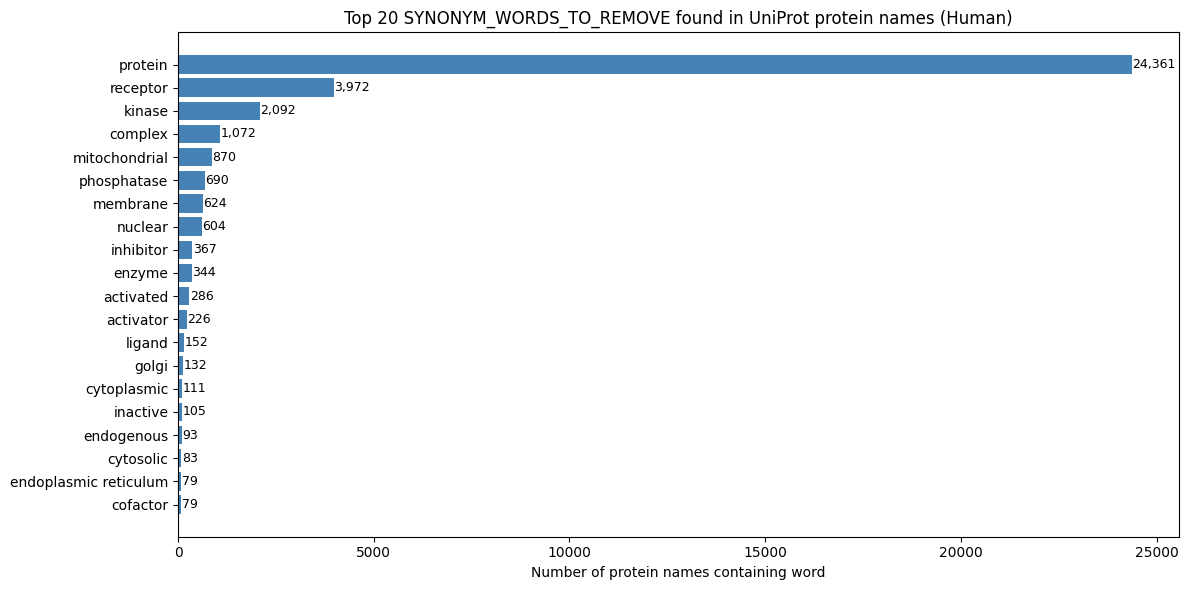


Summary:
  Total protein names: 111,978
  Names containing at least one word from list: 36,342
  Words found: 43/52


In [5]:
# Visualize the distribution
import matplotlib.pyplot as plt

# Filter to words with count > 0
words_with_counts = [(w, c) for w, c in sorted_counts if c > 0]

if words_with_counts:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    words = [w for w, c in words_with_counts[:20]]  # Top 20
    counts = [c for w, c in words_with_counts[:20]]
    
    bars = ax.barh(range(len(words)), counts, color='steelblue')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()  # Highest at top
    ax.set_xlabel('Number of protein names containing word')
    ax.set_title('Top 20 SYNONYM_WORDS_TO_REMOVE found in UniProt protein names (Human)')
    
    # Add count labels
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                f'{count:,}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    total_matches = sum(counts)
    print(f"\nSummary:")
    print(f"  Total protein names: {len(names2uniprot_human):,}")
    print(f"  Names containing at least one word from list: {total_matches:,}")
    print(f"  Words found: {len(words_with_counts)}/{len(SYNONYM_WORDS_TO_REMOVE)}")
else:
    print("No words from SYNONYM_WORDS_TO_REMOVE found in protein names.")
